In [1]:
import masking_effects_on_xai_techniques.utils as utils
import masking_effects_on_xai_techniques.plot_creator as plot_creator
import masking_effects_on_xai_techniques.plot_creator_2 as plot_creator_2
import os
import numpy as np
import matplotlib.pyplot as plt

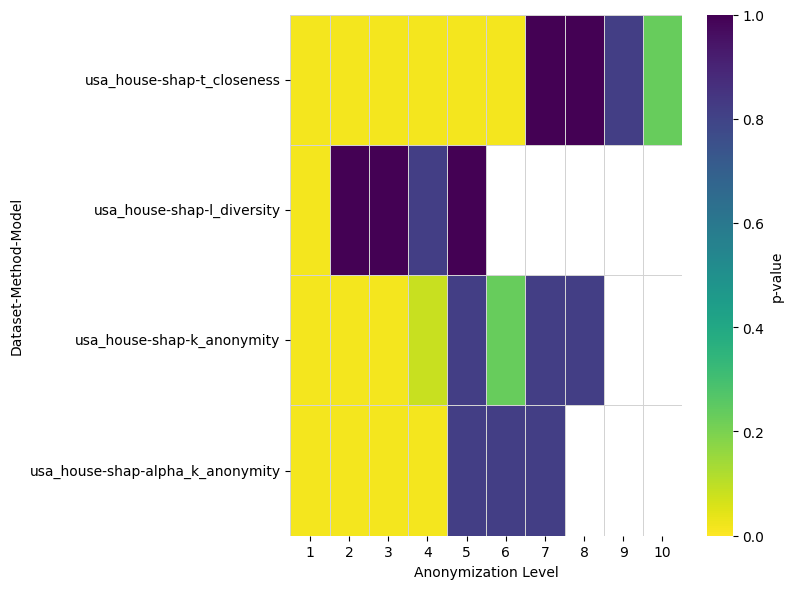

In [4]:
pl = plot_creator_2.PlotCreator(["usa_house","cervic_cancer"])
pl.plot_heatmap(datasets=['usa_house'], methods=['shap'])

# Utility vs Generalization

In [2]:
#adult = plot_creator.Comparer("adult", "..", ["l", "a"])
#adult.plot_line()

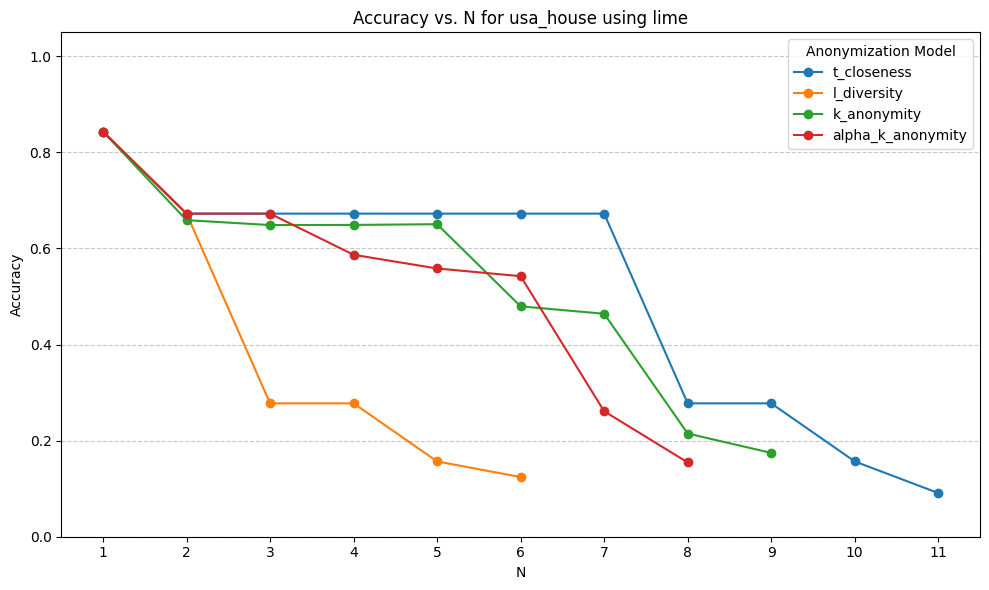

In [3]:
usa_house = plot_creator.Comparer("usa_house", "..")
usa_house.plot_accuracy("lime")

The change in accuracy graduarly fall for alpha-k-anonymity indicating that higher constraints are slowly met my generalizing a feature one at a time.  Why? A lot of equivalence classes contain elements from different target classes. Once alpha becomes low enough, there must be a higher number of different target classes in an equivalence class which only occurs when granularity is lost
The quick drop in accuracy for l_diversity indicates that it must quickly generalize much of the dataset to fulfill the requirement. Probably because of the way the target classes have been constructed. Outliers have been removed since we are talking about houses which most of the time are quite similar, instances that is part of the same target class can be expected to look rather similar. An l-diversity of 2 can rather easily be obtained, because all classes border at least one other class, meaning they probably easily have some instances that share a lot of feature values. Once l become larger than two, for the two outer most target classes they must be part of an equivalence class where instances of a non-neighbouring target class also are. This happens rarely. The data must therefore loose a lot of granularity before it happens  
Remember, k_anonimity increase exponential. Initiallly it does not need to generalize the dataset further because k does not change a lot and the dataset is so big. Once k gets big enough we loose a lot of granularity  
I am not sure why t-closeness is so flat for so long

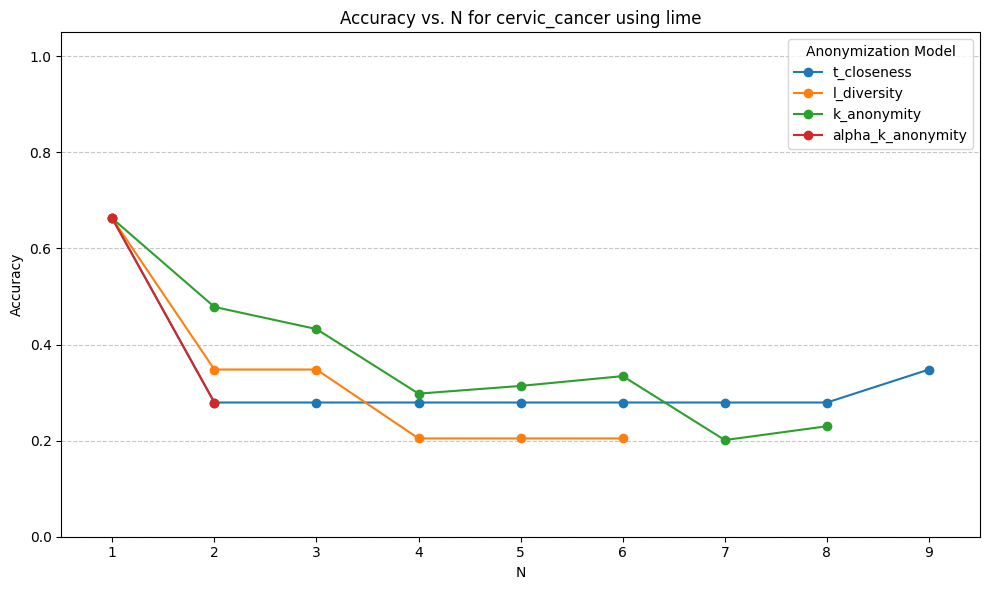

In [4]:
cervic_cancer = plot_creator.Comparer("cervic_cancer", "..", [])
cervic_cancer.plot_accuracy("lime")

This dataset has a lot of features. Most of these features are binary except a few numeric features. These numeric features are instanly genralized to a very high generalization, because the high number of binary features makes it quite probably that just one is different and the Mondrian algorthm always genrealizes the feature with the most diversity. Once all the features have been generalized to a level where they are all binary, they are all anonymized in the order in which they appear in the dataframe column.  
Here we see for both t_closeness and k_anonymity that the accuracy actually increase as the datasets are generalized even more. Why is this? Again, the curse of dimensionality. As more and more features are suppressed, the dimensionality is slowly reduced. The accuracy is alrady very low, so this lower dimensional function might just perform a little better.  
Apart from that, it can be pointless making conclusions from this graph, since the accuracy is so low

# Importance

## Lime

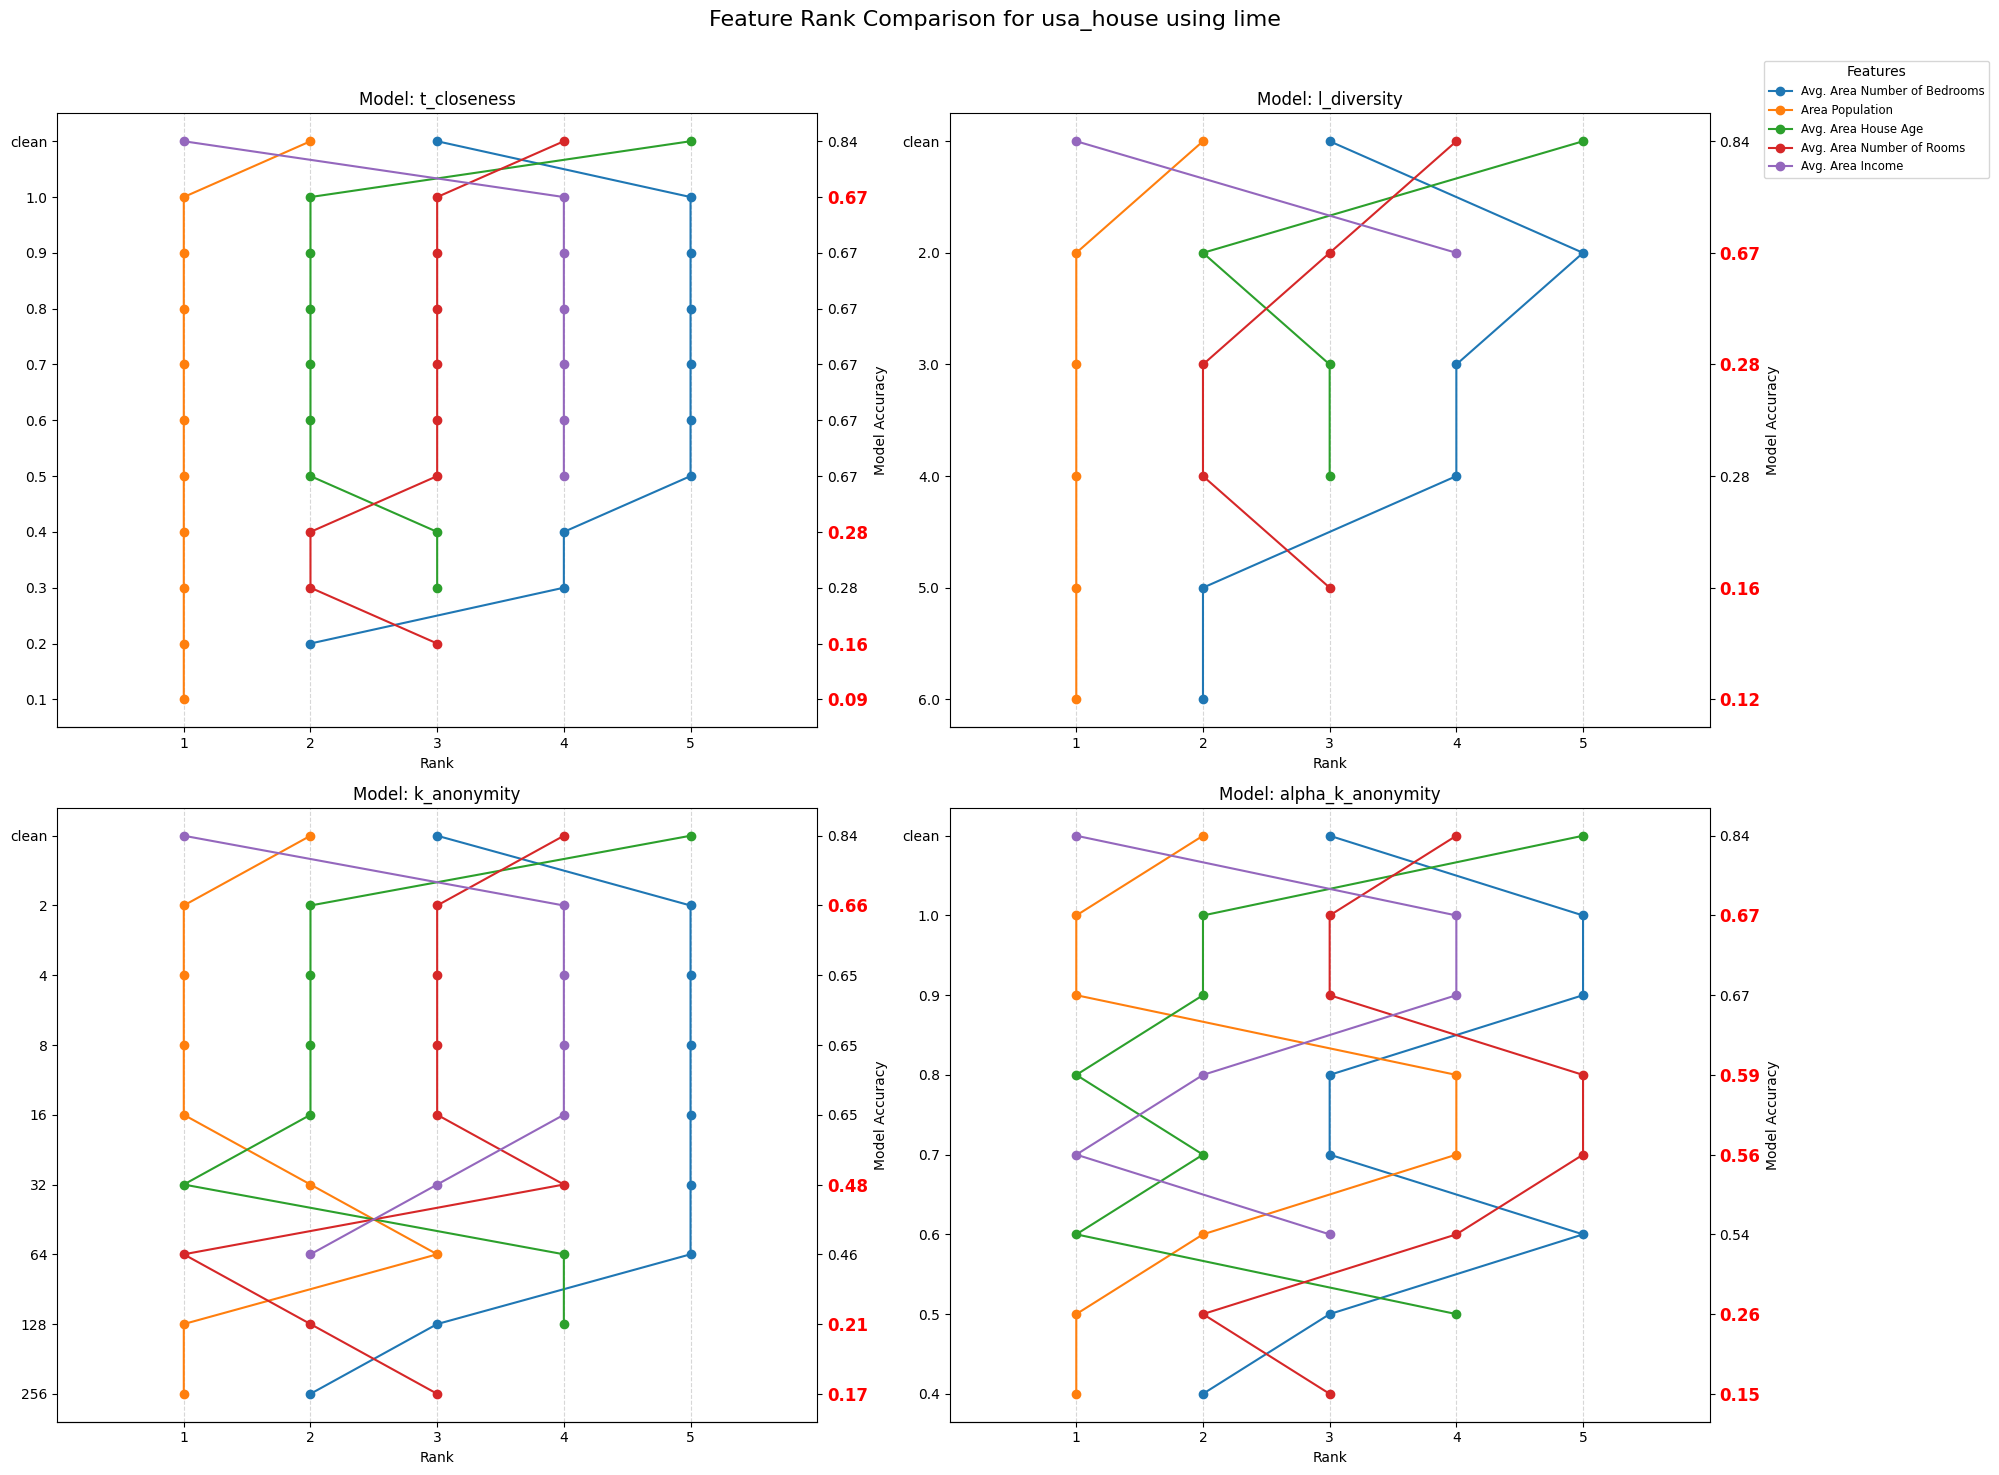

In [5]:
usa_house.plot_line("lime")

The importance of features are all over the place. The features that disappear first are the features with the most diversity. Here, all the features have taxonomy trees of same structure, so they simply get generalized in the "rolling" order they appear in the dataframe. 
Sadly, it is the most important feature that is generalized first, since it is the one that disappears the fastest.   
While t-closeness looks very stable (although the ranking is changed) and k_anonimity looks stable as well, they just look stable because the initial dataset satisfy the values for k and t multiple times. In fact, every time it is generalized the rankings of the feature changes. 

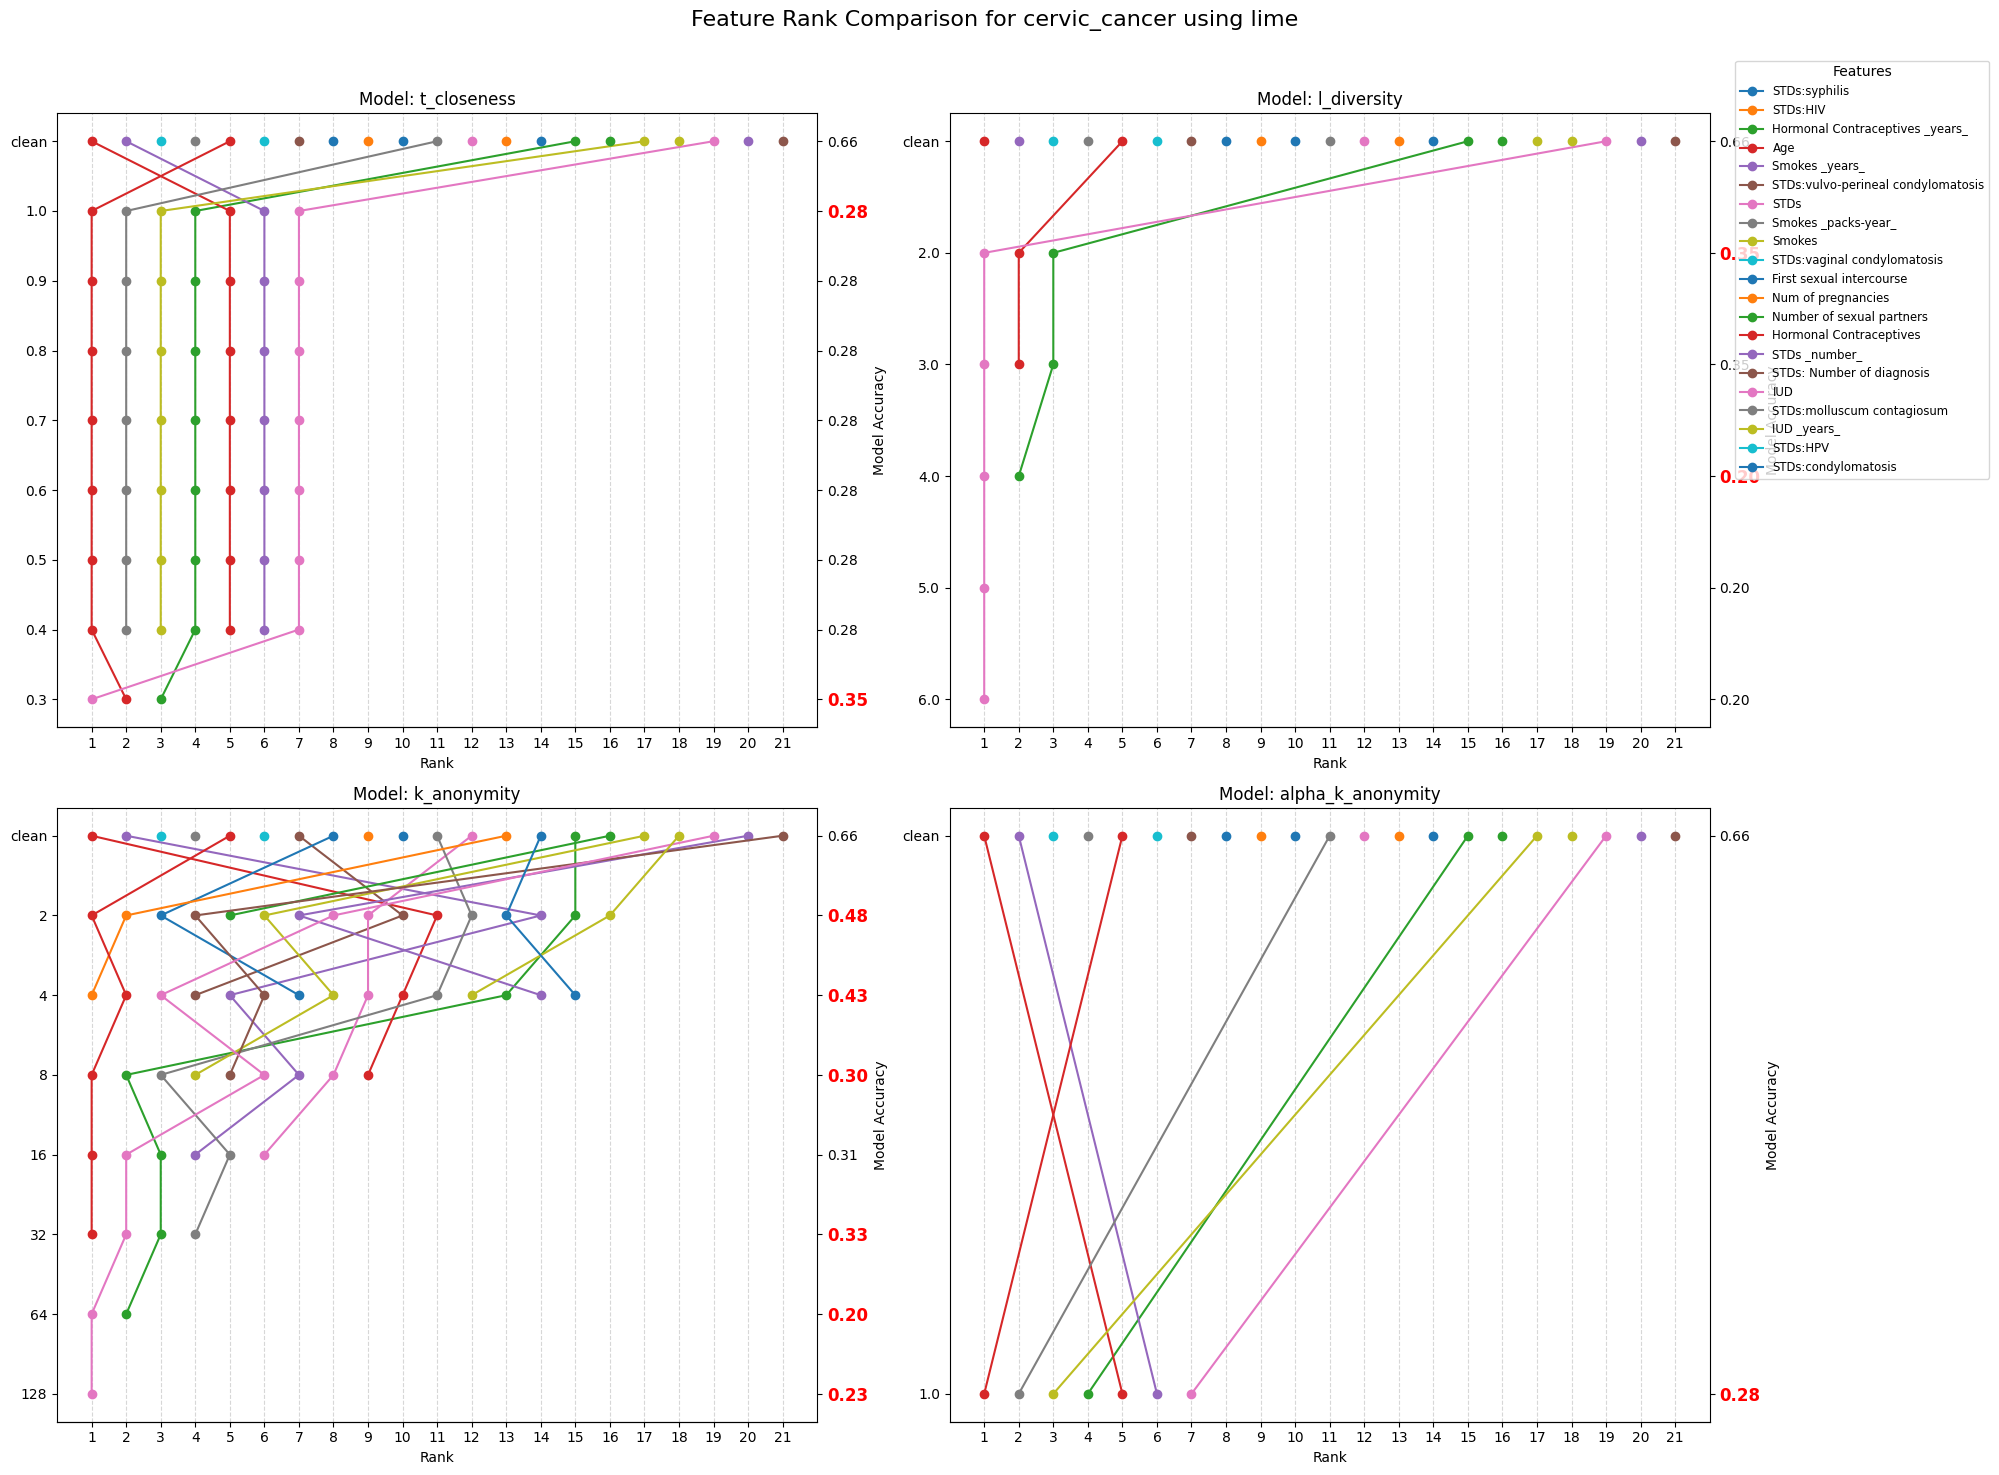

In [6]:
cervic_cancer.plot_line("lime")

It looks quite bad. Again, t closeness looks stable only because the first dataset that satisfy $t=1.0$ also satisfies $t=0.4$, and we are basically seeing the same dataset throughout the entire graph.  
l-diversity becomes very generalized very quicklly. It is rather hard to wrap your head around this dataset because it has so many features. The fact that it must be generalized so much just to achieve $l=2$ while you can have much more features for $k=8$ indicates that some equivalence classes all belong to the same target class. In this dataset, the majority of people have no diagnosis (88% of the 800 or so instances) it has been undersamled and the other tagert classes (many with only 12 instances) have been over-sampled. Since around 230 instances have been created from the original 12 instances, all these 230 instances are quite similar. In a not so generalized dataset an equivalence class will therefore not contain that many mixed values. The 230 real instances part of the common target class most likely covers other areas of the high dimensional feature space, whereas the 12 instances can only span so much of high dimensional state space.  
Also, the fact alpha-k-anonymity can only be achived for $\alpha=1$ indicates that the equivalence classes for $l>1$ must be very large, since they canntot even satisfy $\alpha=0.9$  
**IDEA** maybe go back and remove some of the target features? The least common one. Also consider removing less important features. Or maybe use PCA  

# SHAP

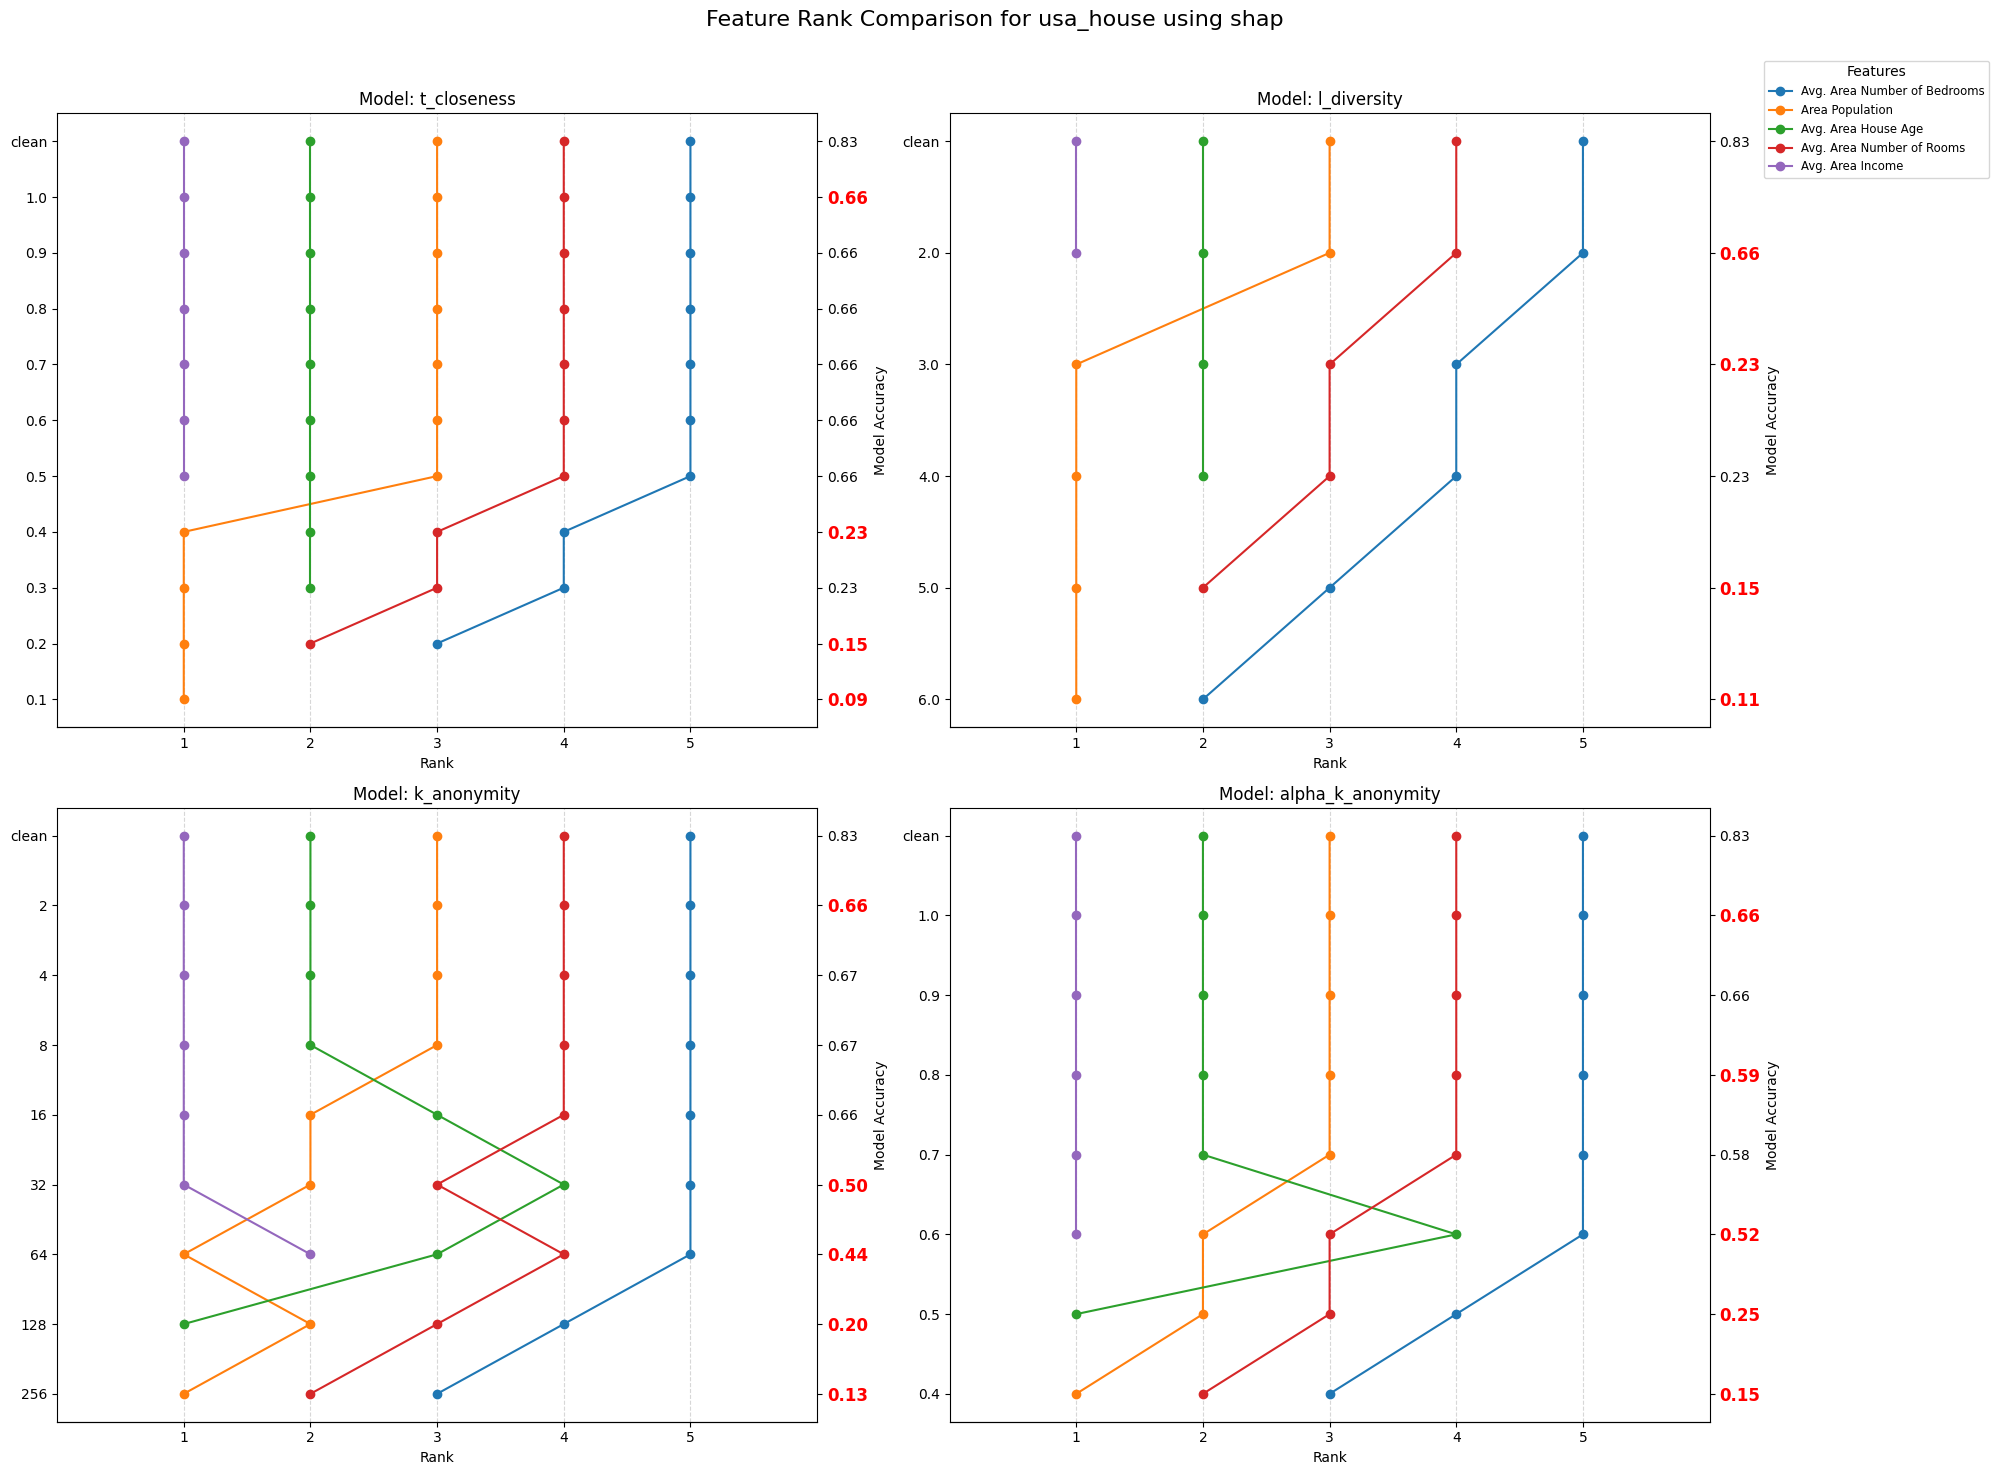

In [7]:
usa_house.plot_line("shap")

SHAP is more stable than lime  
Note, the datasets at k anonimity 8 and 16 are actually not the same, the accuracy just does not change significantly. The importance of the features change when using SHAP. When using lime, that is not the case however.  
Multiple times when a generalization occours, the ranking stay the same. That means that SHAP produces more stable feature rankings across generalized datasets. 

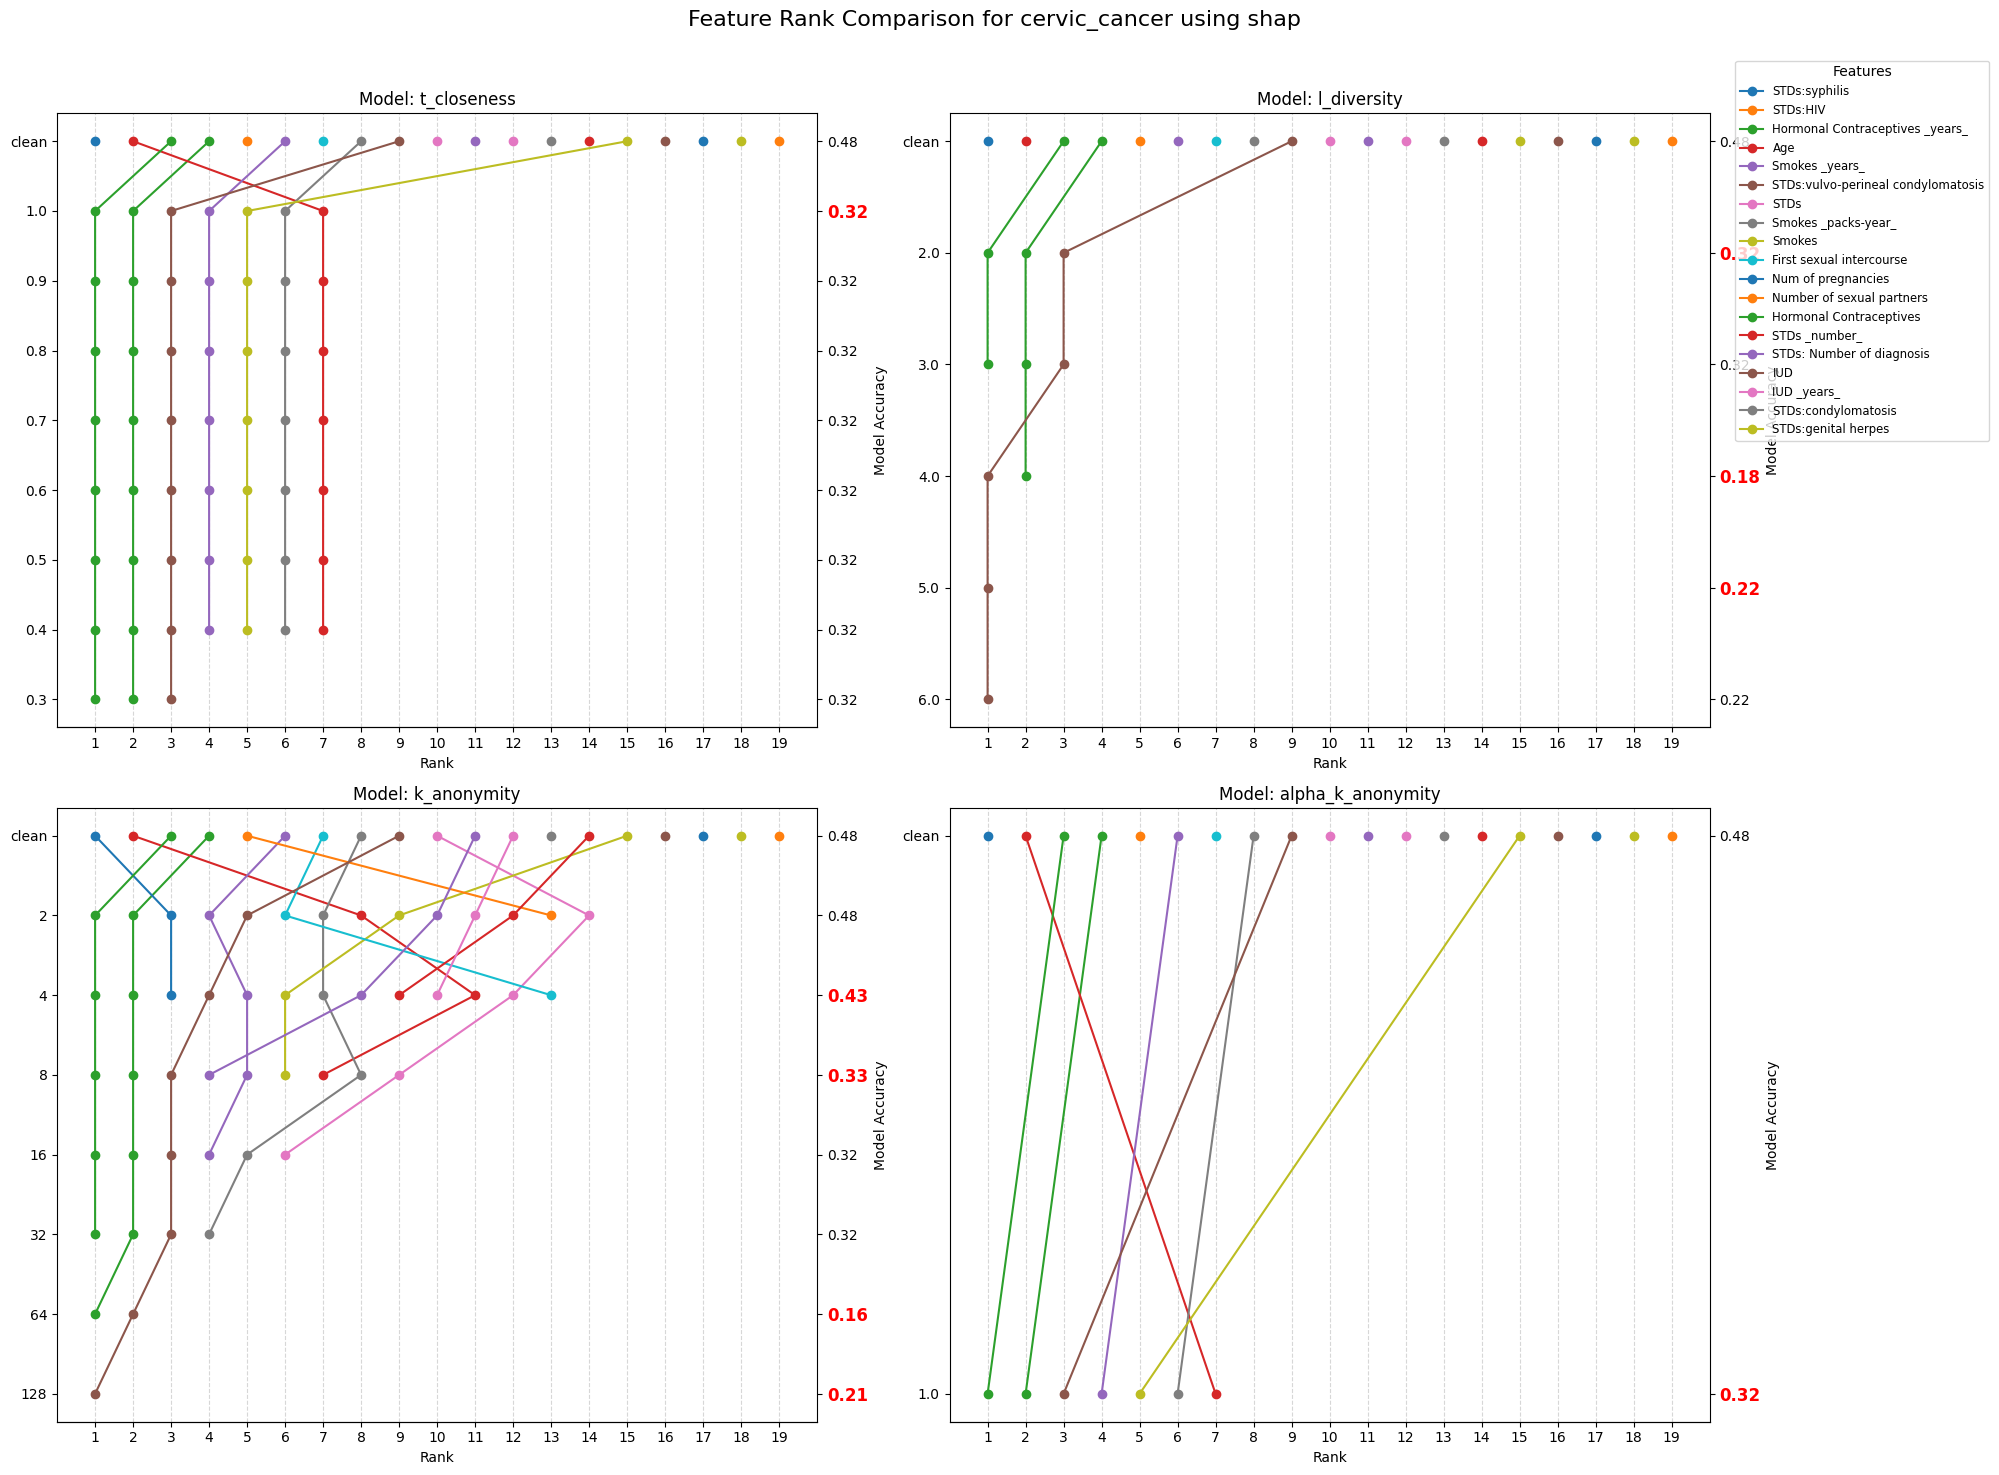

In [8]:
cervic_cancer.plot_line("shap")

Same story. SHAP looks quite a bit more stable. 

# Old

The p-value of the kendaltau statistic is the p value for the null hypothesis: *The rank correlation is zero*. If the rank correlation is zero, the two rankings are independent, i.e. they are rather random compared to one another, and the do not correlate with one another at all. Low p-values indicate that the alternative hypothesis is true, i.e. *the rank correlation is nonzero*, meaning the two rankings are similar. Note, it is a two sided hypothesis test, so we are investigating if there is a positive or a negative correlation between the two orderings. 

In [ ]:
plot_creator.plot_comparison(
    [comparer_lime_k, comparer_shap_k],
    ["LIME", "SHAP"],
    "Adult k-anonymity"
)

In `k_anonymity` there are more differences between the different datasets. Different levels of hiearchies have been applied to each layer. It also makes the importance of the vectors more all over the place

In [ ]:
plot_creator.plot_comparison(
    [comparer_lime_t, comparer_shap_t],
    ["LIME", "SHAP"],
    "Adult t-closeness"
)

in `t_closeness` there is two big changes in the anonymizaiton structure. One between clean and 1.0 and one between 0.8 and 0.7. This is also clearly seen in the data $he$